In [1]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [7]:
# =========================
# 2. DATA PATHS
# =========================
train_path = r"D:\Downloads\PlantVillage\train"
valid_path = r"D:\Downloads\PlantVillage\val"

In [9]:
# =========================
# 3. PREPROCESSING
# =========================
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

valid_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical'
)

valid_data = valid_datagen.flow_from_directory(
    valid_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical'
)


Found 43444 images belonging to 38 classes.
Found 10861 images belonging to 38 classes.


In [11]:
# =========================
# 4. CNN MODEL
# =========================
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(train_data.num_classes, activation='softmax'))

C:\Users\aasth\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
# =========================
# 5. COMPILE
# =========================
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
# =========================
# 6. TRAIN
# =========================
history = model.fit(
    train_data,
    epochs=5,
    validation_data=valid_data
)

Epoch 1/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 1732s 1s/step - accuracy: 0.4701 - loss: 1.9093 - val_accuracy: 0.7283 - val_loss: 0.8993
Epoch 2/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 821s 605ms/step - accuracy: 0.6591 - loss: 1.1315 - val_accuracy: 0.8005 - val_loss: 0.6528
Epoch 3/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 1241s 914ms/step - accuracy: 0.7197 - loss: 0.9075 - val_accuracy: 0.8136 - val_loss: 0.5867
Epoch 4/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 807s 594ms/step - accuracy: 0.7589 - loss: 0.7721 - val_accuracy: 0.8390 - val_loss: 0.4948
Epoch 5/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 764s 563ms/step - accuracy: 0.7863 - loss: 0.6779 - val_accuracy: 0.8539 - val_loss: 0.4433


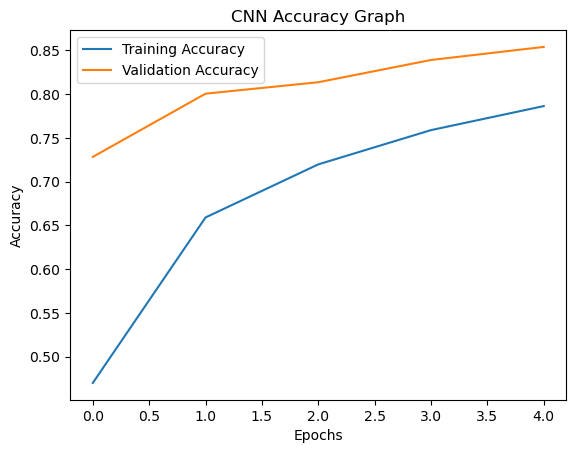

In [17]:
# =========================
# 7. GRAPH
# =========================
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("CNN Accuracy Graph")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()